# SUR 2025/2026 — Final report figures

Clean, pastel, no grey, no overlapping labels. Every figure is engineered
for the 3-page PDF so it reads well at small scale.

**Outputs:** `docs/figures/fig{1..7}.{pdf,png}` (vector PDF + 300 DPI PNG).

In [1]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

from __future__ import annotations

import pickle
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator, PercentFormatter
from scipy.stats import gaussian_kde, norm
from sklearn.metrics import roc_curve

REPO  = Path.cwd() if Path.cwd().name == "project" else Path.cwd().parent
sys.path.insert(0, str(REPO))
FIG   = REPO / "docs" / "figures"
CACHE = REPO / "cache"
FIG.mkdir(parents=True, exist_ok=True)

## Palette & theme

One hue family per stream, two shades each. Baseline = pale tint,
flagship = saturated pastel. Text is dark navy-ink everywhere — no grey.

In [2]:
P = {
    "audio":        "#7EB3DC",   # pastel blue
    "audio_pale":   "#D1E3F1",
    "image":        "#EFA496",   # dusty coral
    "image_pale":   "#F9D6CE",
    "fusion":       "#85C9AC",   # soft sage
    "fusion_pale":  "#D1E9DC",
    "violet":       "#C3AEDB",   # lilac (MFCC / non-target)
    "violet_pale":  "#E6DBF0",
    "ink":          "#222A3B",
    "subtext":      "#4E5872",
    "accent":       "#D97860",   # terracotta, reserved for threshold
    "grid":         "#F0EDE6",   # very soft cream grid
    "bg":           "#FFFFFF",
}
STREAM       = {"audio": P["audio"],      "image": P["image"],      "fusion": P["fusion"]}
STREAM_PALE  = {"audio": P["audio_pale"], "image": P["image_pale"], "fusion": P["fusion_pale"]}

sns.set_theme(style="white", context="paper")
mpl.rcParams.update({
    "figure.dpi":          140,
    "savefig.dpi":         300,
    "figure.facecolor":    P["bg"],
    "axes.facecolor":      P["bg"],
    "savefig.facecolor":   P["bg"],
    "savefig.bbox":        "tight",
    "savefig.pad_inches":  0.12,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
    "font.family":         "sans-serif",
    "font.sans-serif":     ["Inter", "SF Pro Text", "Helvetica Neue",
                            "Helvetica", "Arial", "DejaVu Sans"],
    "font.size":           11.0,
    "text.color":          P["ink"],
    "axes.titlesize":      13.0,
    "axes.titleweight":    "semibold",
    "axes.titlelocation":  "left",
    "axes.titlepad":       14,
    "axes.titlecolor":     P["ink"],
    "axes.labelsize":      11.0,
    "axes.labelcolor":     P["ink"],
    "axes.labelpad":       9,
    "axes.edgecolor":      P["ink"],
    "axes.linewidth":      0.9,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "xtick.color":         P["ink"],
    "ytick.color":         P["ink"],
    "xtick.labelsize":     10.0,
    "ytick.labelsize":     10.0,
    "xtick.major.width":   0.9,
    "ytick.major.width":   0.9,
    "xtick.major.size":    3.4,
    "ytick.major.size":    3.4,
    "xtick.direction":     "out",
    "ytick.direction":     "out",
    "legend.fontsize":     10.0,
    "legend.frameon":      False,
    "lines.linewidth":     2.2,
    "lines.markersize":    7.0,
    "lines.markeredgewidth": 1.8,
})


def style(ax, *, y_label="", title=None, ymax=None, ymin=0, y_int=False):
    ax.set_xlabel("")
    ax.set_ylabel(y_label)
    if title is not None:
        ax.set_title(title)
    if ymax is not None:
        ax.set_ylim(ymin, ymax)
    if y_int:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.grid(True, color=P["grid"], linewidth=1.0, zorder=0)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)


def label_bars(ax, xs, ys, *, color, pad_frac=0.02, weight="semibold",
               fmt="{:.2f}%", fontsize=10):
    offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * pad_frac
    for x, y in zip(xs, ys):
        if y is None or np.isnan(y):
            continue
        ax.text(x, y + offset, fmt.format(y),
                ha="center", va="bottom", color=color,
                fontsize=fontsize, fontweight=weight)


def save(fig, name: str) -> None:
    for ext in ("pdf", "png"):
        fig.savefig(FIG / f"{name}.{ext}")

## Figure 1 — Audio: GMM covariance type (E037)

Single-hue ablation: 3 pale bars + 1 saturated winner. Same hue → no grey.

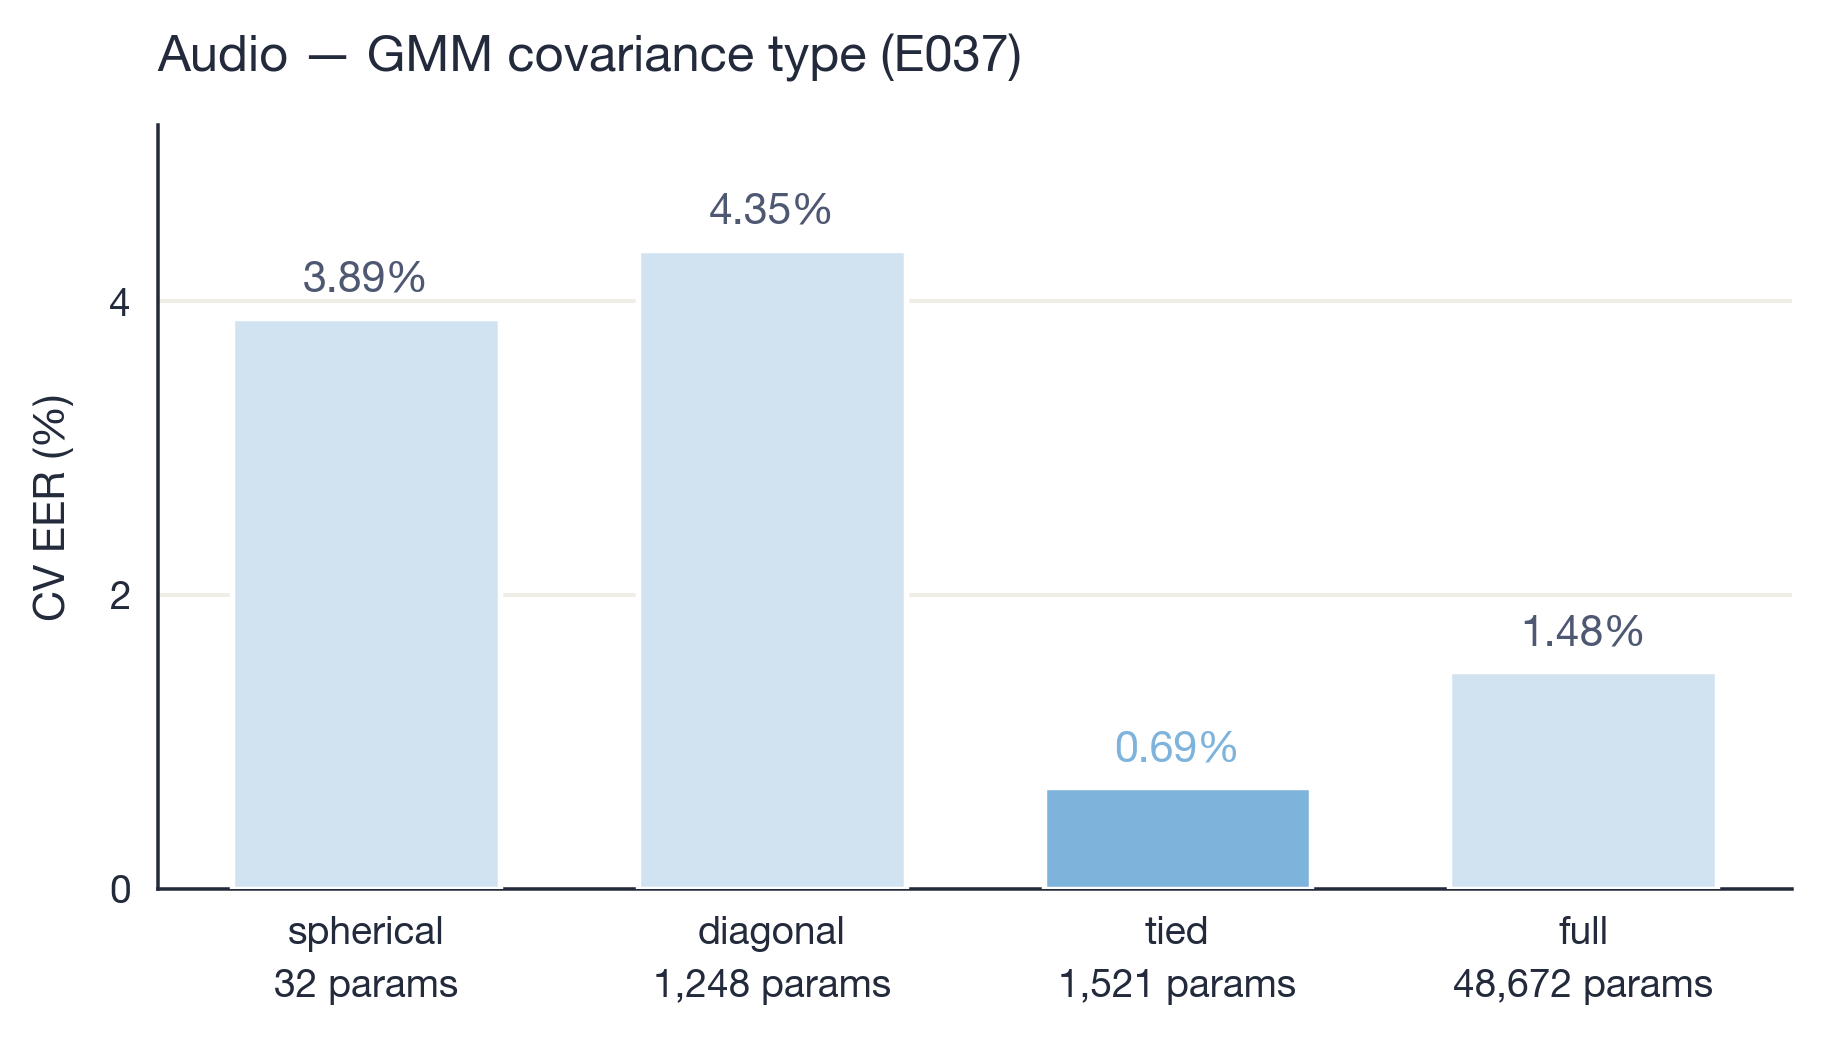

In [3]:
cov = pd.DataFrame({
    "covariance": ["spherical", "diagonal", "tied", "full"],
    "EER":        [3.89, 4.35, 0.69, 1.48],
    "params":     [32, 1248, 1521, 48672],
})

fig, ax = plt.subplots(figsize=(6.6, 3.8))
xs = np.arange(len(cov))
colors = [P["audio"] if c == "tied" else P["audio_pale"] for c in cov["covariance"]]
ax.bar(xs, cov["EER"], color=colors, width=0.66,
       edgecolor="white", linewidth=1.4, zorder=3)

style(ax, y_label="CV EER (%)", ymax=5.2,
      title="Audio — GMM covariance type (E037)", y_int=True)
ax.set_xticks(xs)
ax.set_xticklabels([f"{c}\n{n:,} params" for c, n in zip(cov['covariance'], cov['params'])],
                   fontsize=10, linespacing=1.6)

# bold value labels in matching colour; no error bars (they add noise here
# and the std is already in the CLAUDE.md table).
for x, v, is_win in zip(xs, cov["EER"], cov["covariance"] == "tied"):
    col = P["audio"] if is_win else P["subtext"]
    wt  = "bold" if is_win else "semibold"
    ax.text(x, v + 0.12, f"{v:.2f}%", ha="center", va="bottom",
            color=col, fontsize=11, fontweight=wt)

fig.tight_layout()
save(fig, "fig1_covariance_ablation")
plt.show()

## Figure 2 — Image: adversarial rotation (E033)

Paired bars, same hue family (pale → saturated). No delta pills, no
callouts — the bar height already tells the story.

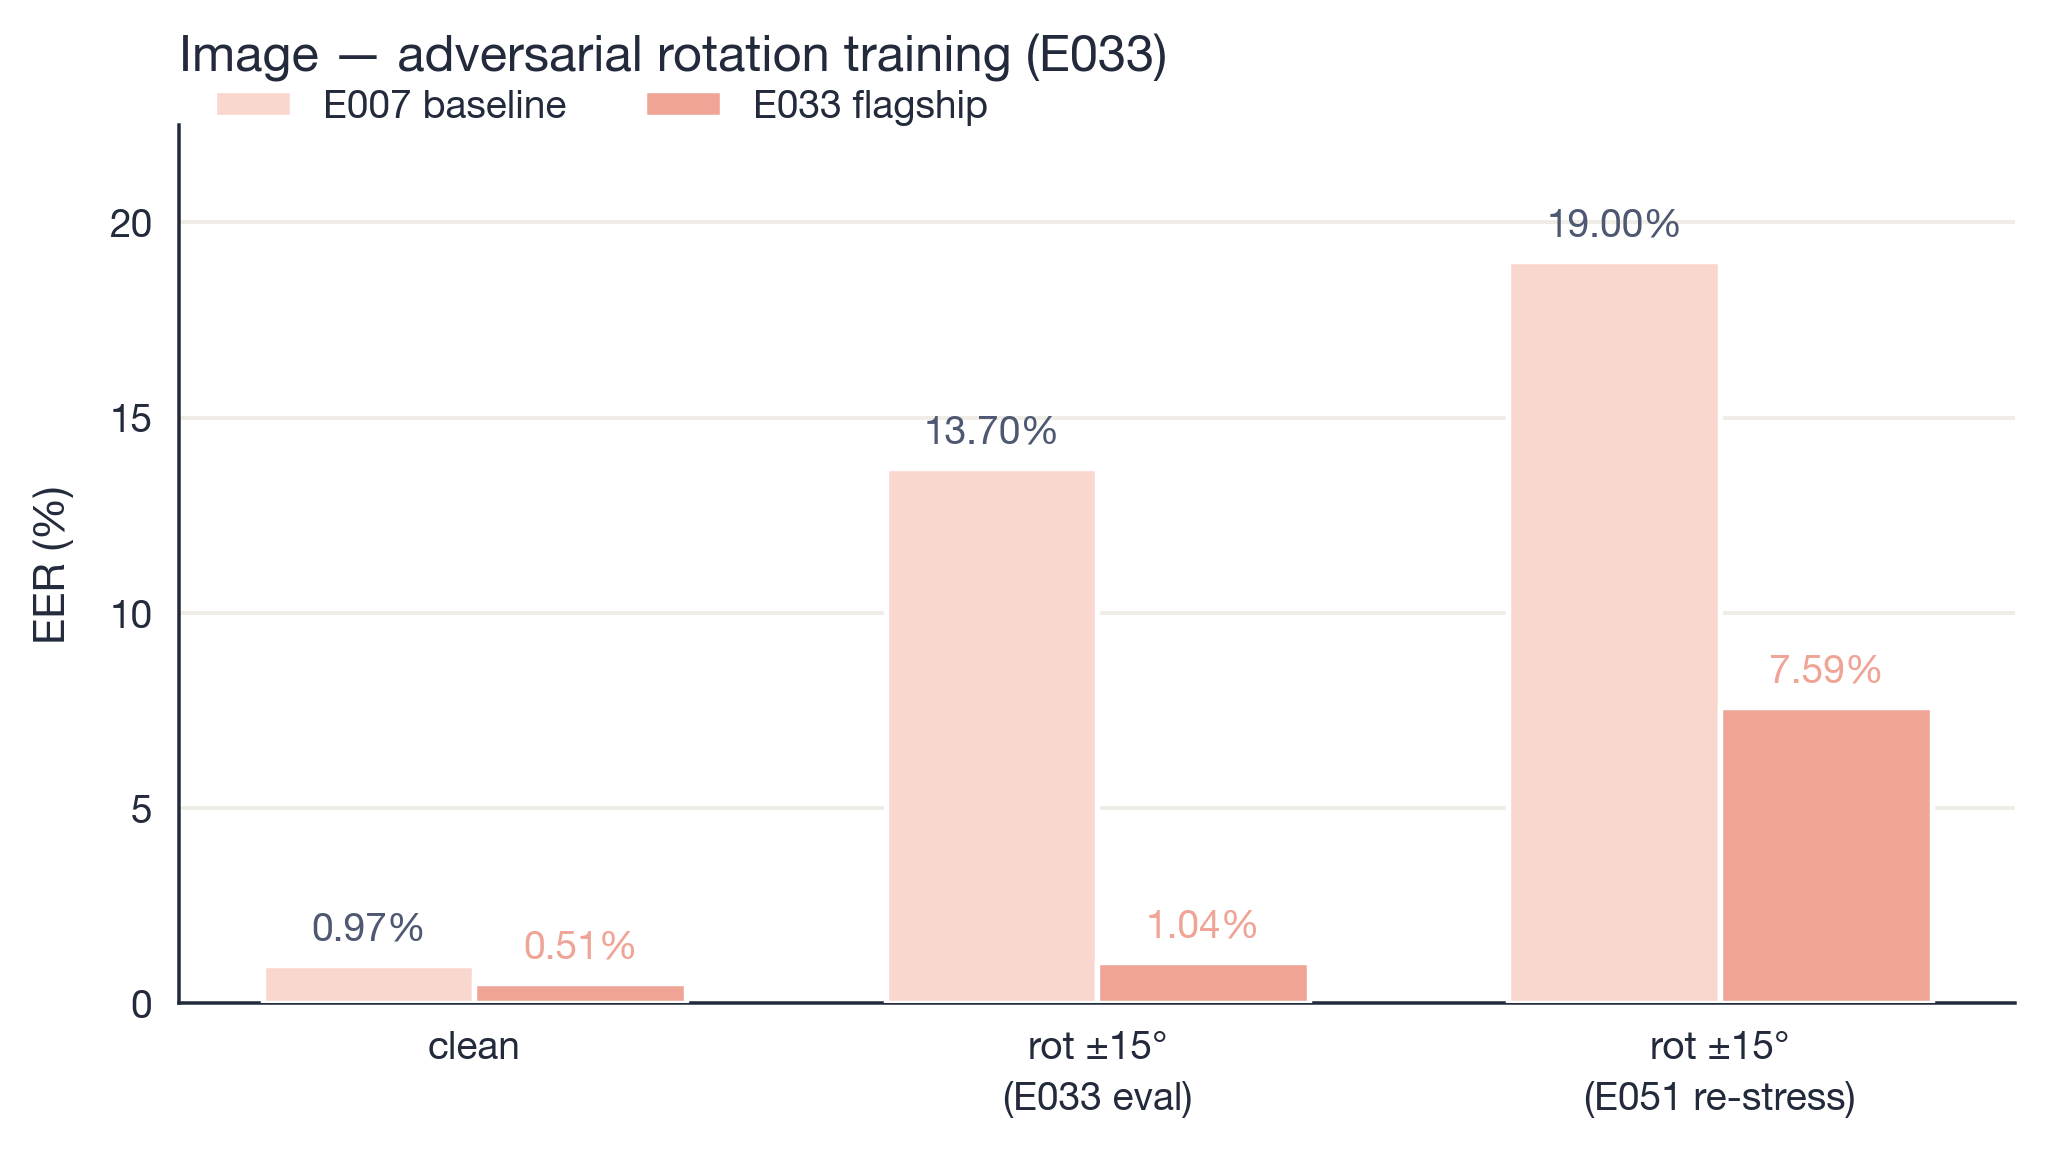

In [4]:
conds = ["clean", "rot ±15°\n(E033 eval)", "rot ±15°\n(E051 re-stress)"]
baseline = np.array([0.97, 13.70, 19.00])
flagship = np.array([0.51,  1.04,  7.59])

x = np.arange(len(conds))
w = 0.34
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.bar(x - w/2, baseline, w, color=P["image_pale"], edgecolor="white",
       linewidth=1.4, zorder=3, label="E007 baseline")
ax.bar(x + w/2, flagship, w, color=P["image"], edgecolor="white",
       linewidth=1.4, zorder=3, label="E033 flagship")

style(ax, y_label="EER (%)", ymax=22.5,
      title="Image — adversarial rotation training (E033)", y_int=True)
ax.set_xticks(x); ax.set_xticklabels(conds, linespacing=1.5)

label_bars(ax, x - w/2, baseline, color=P["subtext"], weight="regular")
label_bars(ax, x + w/2, flagship, color=P["image"], weight="bold")

ax.legend(loc="upper left", ncol=2, bbox_to_anchor=(0.0, 1.08))
fig.tight_layout()
save(fig, "fig2_adv_rot_robustness")
plt.show()

## Figure 3 — Audio: codec-bandwidth robustness (E052)

Two conditions, two systems. Nothing else.

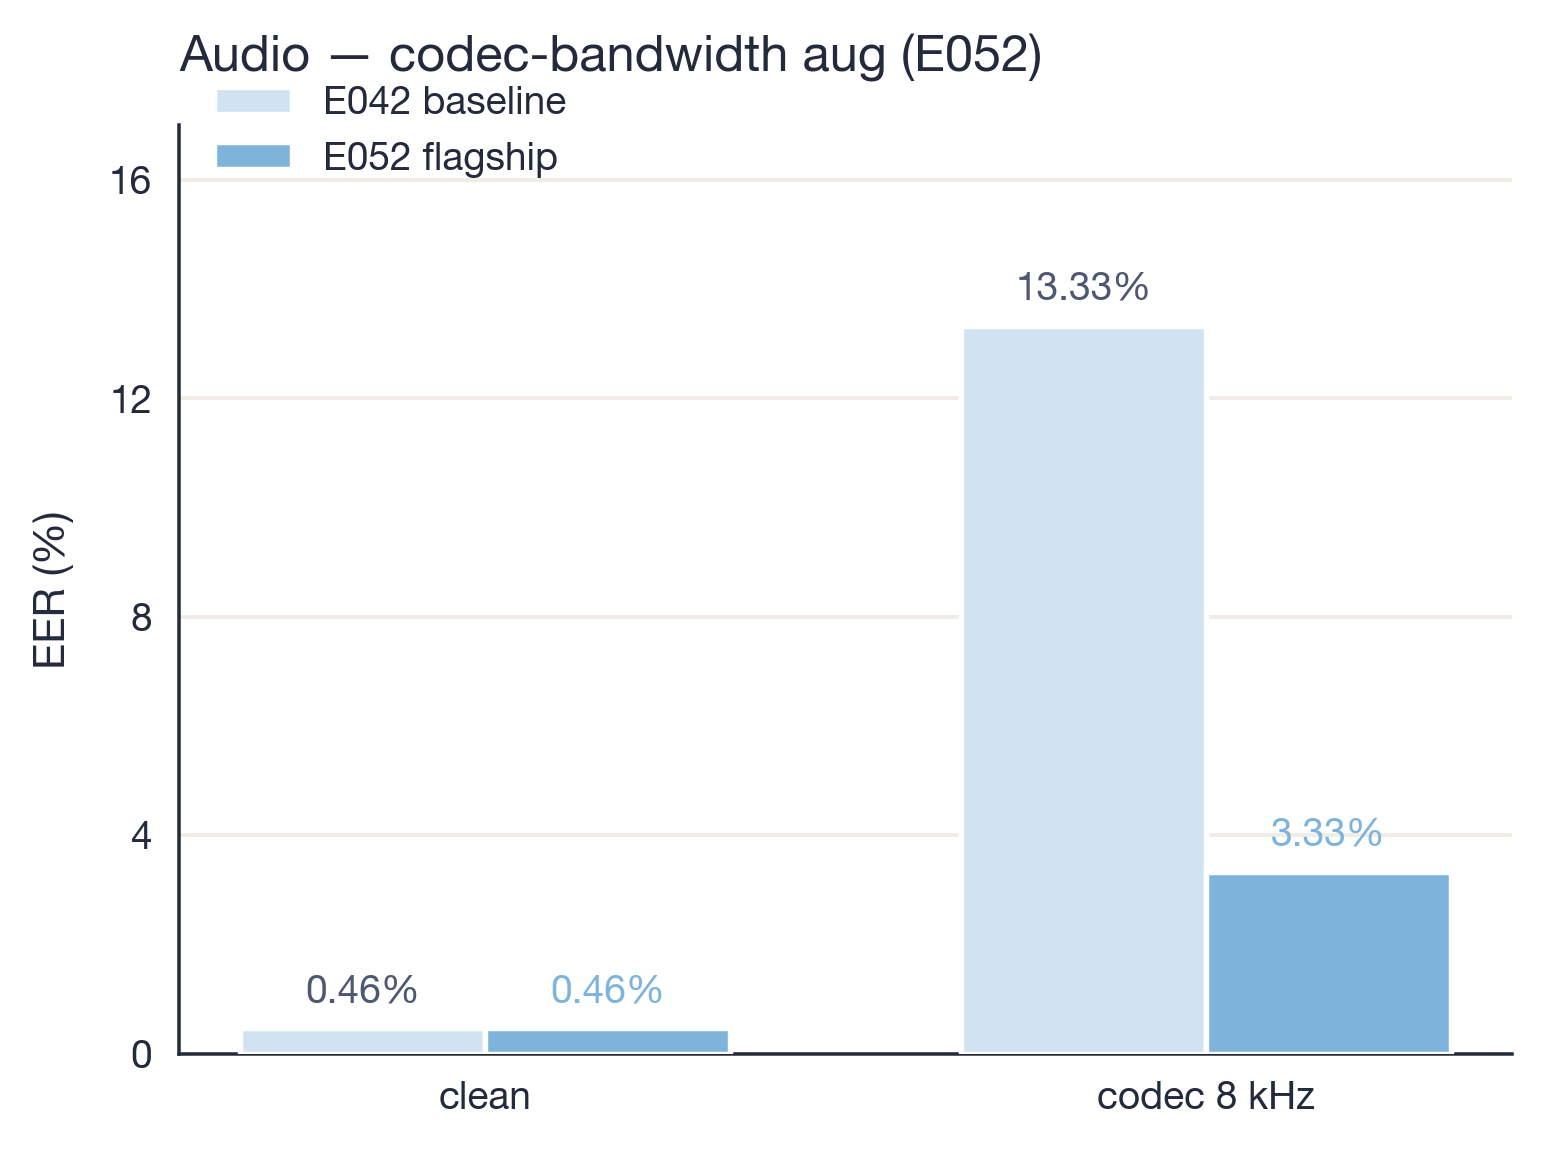

In [5]:
conds = ["clean", "codec 8 kHz"]
baseline = np.array([0.46, 13.33])
flagship = np.array([0.46,  3.33])

x = np.arange(len(conds))
w = 0.34
fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.bar(x - w/2, baseline, w, color=P["audio_pale"], edgecolor="white",
       linewidth=1.4, zorder=3, label="E042 baseline")
ax.bar(x + w/2, flagship, w, color=P["audio"], edgecolor="white",
       linewidth=1.4, zorder=3, label="E052 flagship")

style(ax, y_label="EER (%)", ymax=17, title="Audio — codec-bandwidth aug (E052)",
      y_int=True)
ax.set_xticks(x); ax.set_xticklabels(conds)
label_bars(ax, x - w/2, baseline, color=P["subtext"], weight="regular")
label_bars(ax, x + w/2, flagship, color=P["audio"], weight="bold")

ax.legend(loc="upper left", ncol=1, bbox_to_anchor=(0.0, 1.08))
fig.tight_layout()
save(fig, "fig3_codec_robustness")
plt.show()

## Figure 4 — Experiment progression

Three facets, one per stream. Log-y. Pastel area under each line adds
softness without clutter. Start / end EERs are the only annotations,
each placed where it can never collide with data or ticks.

/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_13225/2720892751.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


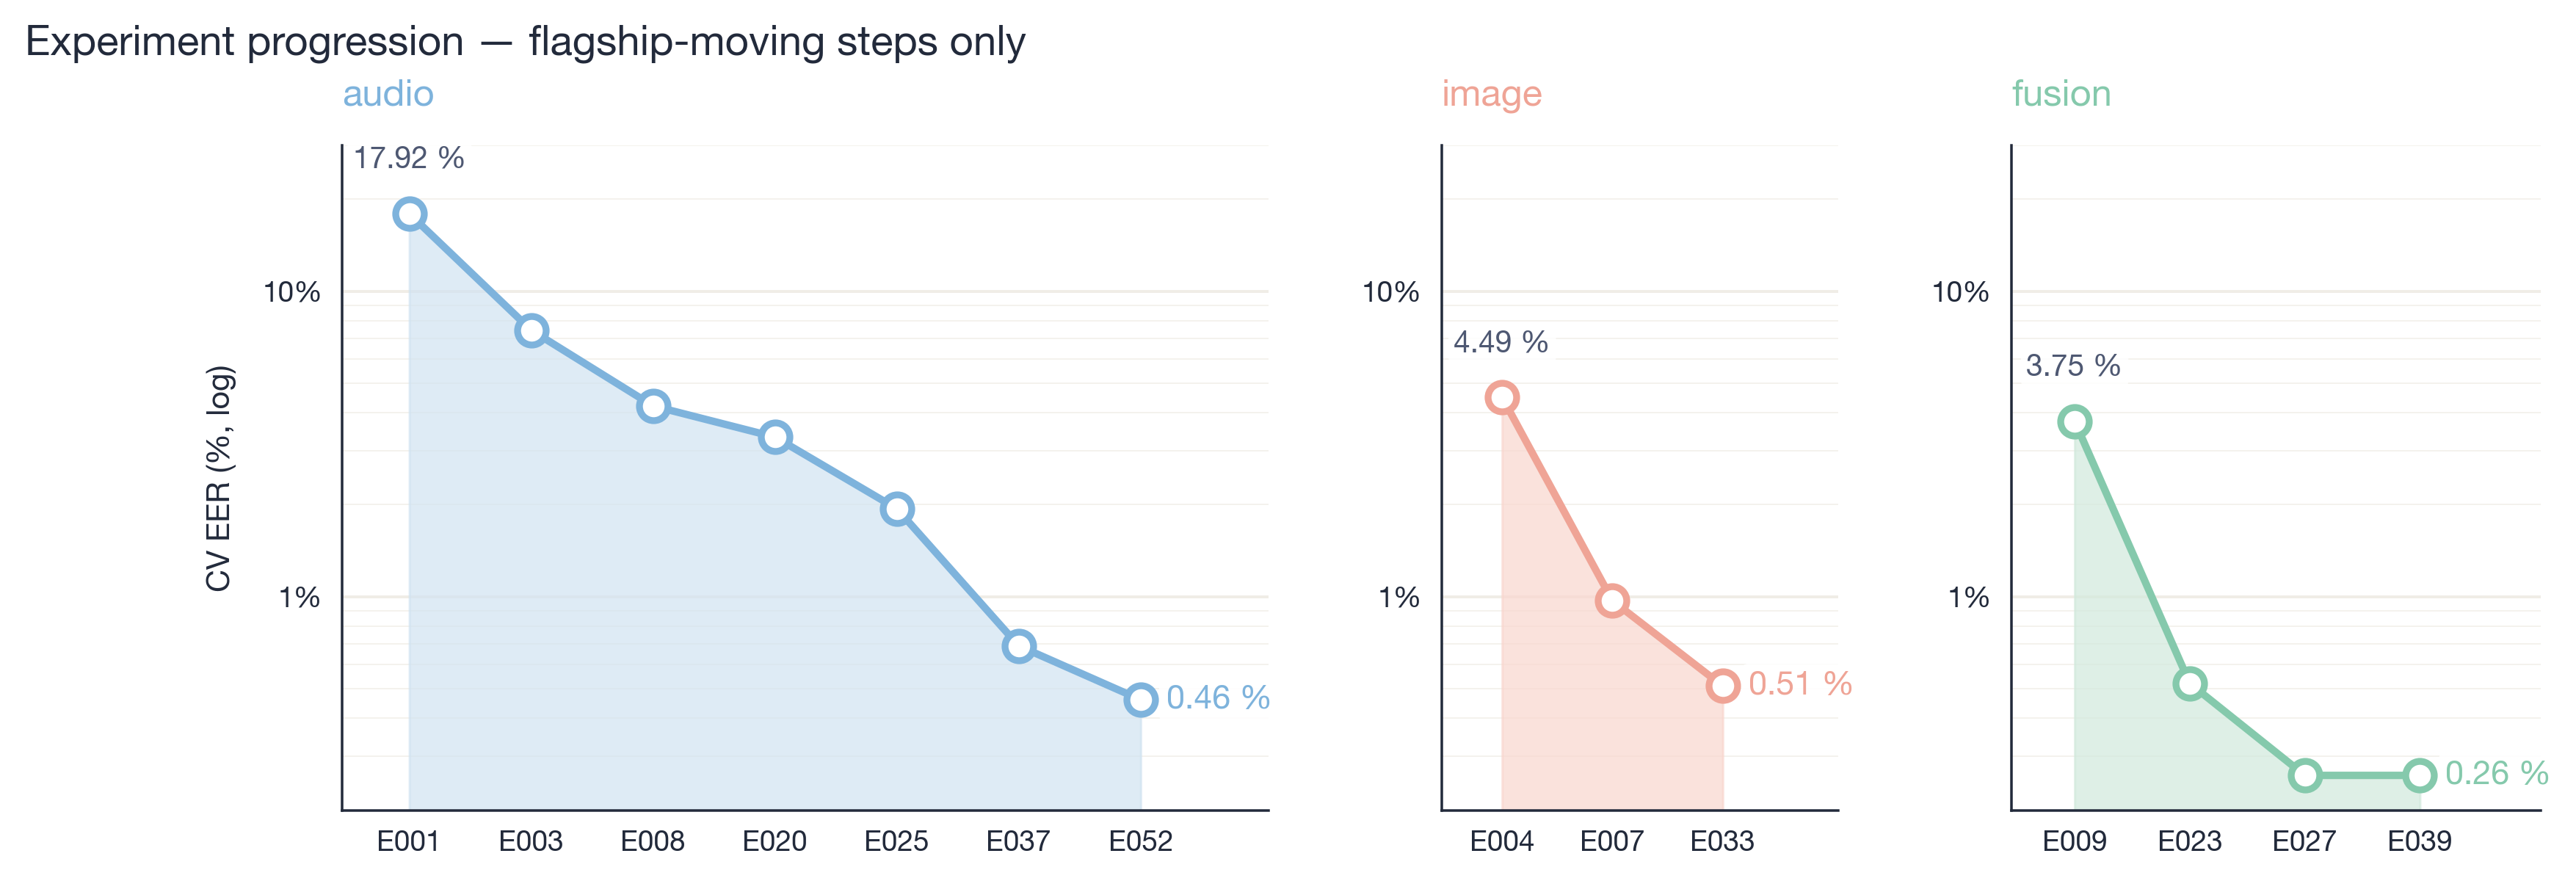

In [6]:
mile = pd.DataFrame([
    ("audio",  1, "E001", 17.92),
    ("audio",  2, "E003",  7.45),
    ("audio",  3, "E008",  4.21),
    ("audio",  4, "E020",  3.33),
    ("audio",  5, "E025",  1.94),
    ("audio",  6, "E037",  0.69),
    ("audio",  7, "E052",  0.46),
    ("image",  1, "E004",  4.49),
    ("image",  2, "E007",  0.97),
    ("image",  3, "E033",  0.51),
    ("fusion", 1, "E009",  3.75),
    ("fusion", 2, "E023",  0.52),
    ("fusion", 3, "E027",  0.26),
    ("fusion", 4, "E039",  0.26),
], columns=["stream", "step", "exp", "EER"])

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.2),
                         gridspec_kw=dict(width_ratios=[7, 3, 4], wspace=0.28))

for ax, stream in zip(axes, ["audio", "image", "fusion"]):
    sub = mile[mile["stream"] == stream].reset_index(drop=True)
    xs, ys = sub["step"].to_numpy(), sub["EER"].to_numpy()
    col, pale = STREAM[stream], STREAM_PALE[stream]

    ax.fill_between(xs, ys, 0.18, color=pale, alpha=0.7, zorder=1)
    ax.plot(xs, ys, marker="o", color=col, linewidth=2.6,
            markerfacecolor="white", markeredgewidth=2.4, markersize=10,
            zorder=3, solid_capstyle="round")

    ax.set_yscale("log")
    ax.set_ylim(0.2, 30)
    ax.set_xlim(xs.min() - 0.55, xs.max() + 1.05)
    ax.set_xticks(xs)
    ax.set_xticklabels(sub["exp"], fontsize=10)
    ax.set_title(stream, color=col, fontweight="semibold")
    ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
    ax.yaxis.grid(True, which="major", color=P["grid"], linewidth=1.0, zorder=0)
    ax.yaxis.grid(True, which="minor", color=P["grid"], linewidth=0.5, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    ax.set_ylabel("CV EER (%, log)" if stream == "audio" else "")

    # First point — above the marker.
    ax.annotate(f"{ys[0]:.2f} %", xy=(xs[0], ys[0]),
                xytext=(0, 14), textcoords="offset points",
                ha="center", va="bottom", fontsize=10.5,
                color=P["subtext"], fontweight="semibold",
                bbox=dict(boxstyle="round,pad=0.18", fc="white",
                          ec="none", alpha=0.85))
    # Last point — label to the RIGHT of the marker with a white bbox so
    # the pastel fill underneath never bleeds through.
    ax.annotate(f"{ys[-1]:.2f} %", xy=(xs[-1], ys[-1]),
                xytext=(9, 0), textcoords="offset points",
                ha="left", va="center", fontsize=11.5,
                color=col, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.22", fc="white",
                          ec="none", alpha=0.92))

fig.suptitle("Experiment progression — flagship-moving steps only",
             fontsize=14.5, fontweight="semibold", color=P["ink"],
             x=0.013, ha="left", y=1.02)
fig.tight_layout()
save(fig, "fig4_progression")
plt.show()

## Figure 5 — Stress-test robustness (E051)

Baseline vs flagship across 5 degradation conditions per modality.
Same hue-pair treatment as Fig 2 / 3.

/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_13225/3589965167.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


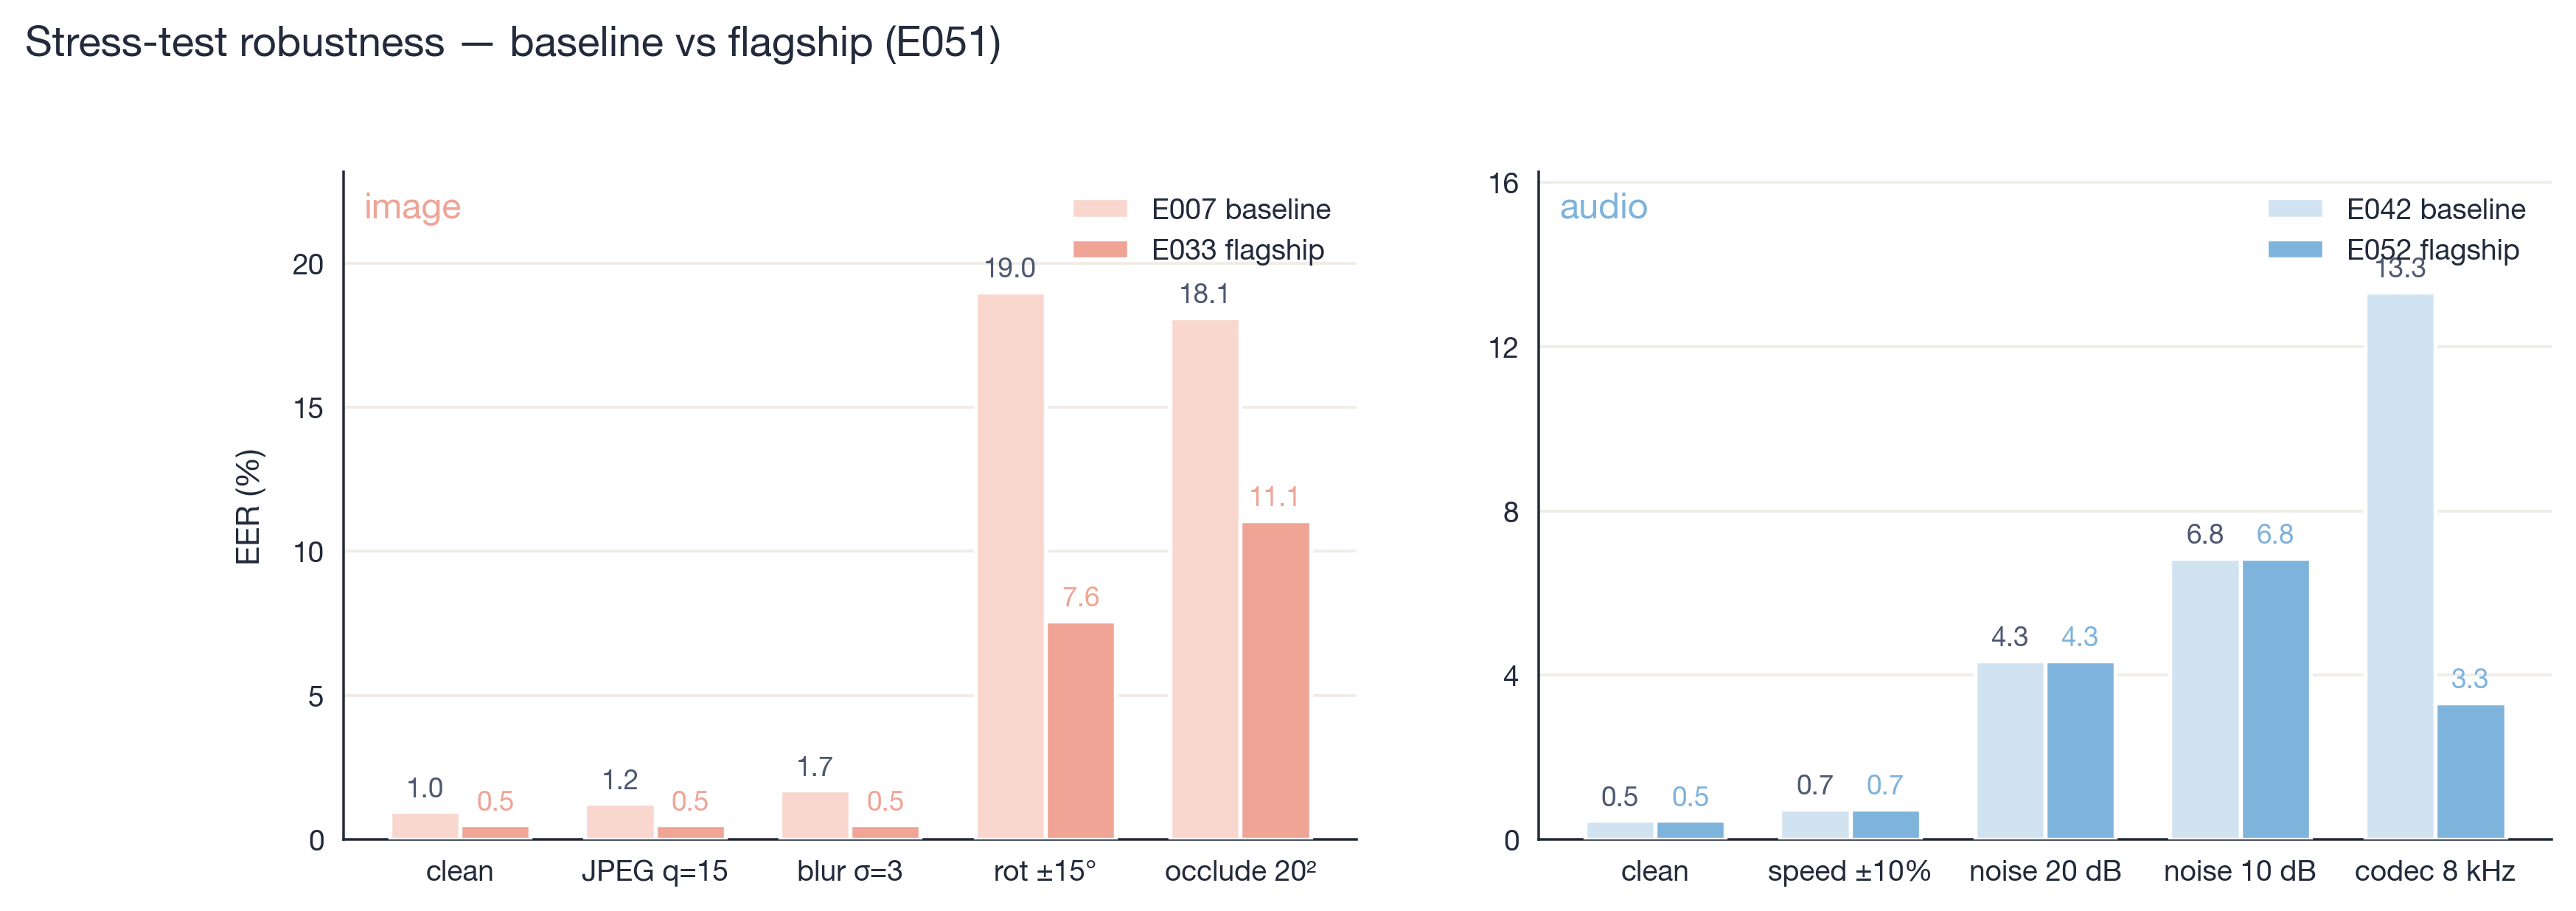

In [7]:
stress = pd.DataFrame([
    ("image", "clean",        "base",  0.97),
    ("image", "JPEG q=15",    "base",  1.25),
    ("image", "blur σ=3",     "base",  1.71),
    ("image", "rot ±15°",     "base", 19.00),
    ("image", "occlude 20²",  "base", 18.10),
    ("image", "clean",        "flag",  0.51),
    ("image", "JPEG q=15",    "flag",  0.51),
    ("image", "blur σ=3",     "flag",  0.51),
    ("image", "rot ±15°",     "flag",  7.59),
    ("image", "occlude 20²",  "flag", 11.06),
    ("audio", "clean",        "base",  0.46),
    ("audio", "speed ±10%",   "base",  0.74),
    ("audio", "noise 20 dB",  "base",  4.35),
    ("audio", "noise 10 dB",  "base",  6.85),
    ("audio", "codec 8 kHz",  "base", 13.33),
    ("audio", "clean",        "flag",  0.46),
    ("audio", "speed ±10%",   "flag",  0.74),
    ("audio", "noise 20 dB",  "flag",  4.35),
    ("audio", "noise 10 dB",  "flag",  6.85),
    ("audio", "codec 8 kHz",  "flag",  3.33),
], columns=["modality", "condition", "which", "EER"])

exp_map = {"image": ("E007", "E033"), "audio": ("E042", "E052")}
fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.2),
                         gridspec_kw=dict(wspace=0.18))

for ax, modality in zip(axes, ["image", "audio"]):
    sub = stress[stress["modality"] == modality]
    conds = sub["condition"].unique().tolist()
    base = sub[sub["which"] == "base"]["EER"].to_numpy()
    flag = sub[sub["which"] == "flag"]["EER"].to_numpy()
    x = np.arange(len(conds)); w = 0.36
    pale, sat = STREAM_PALE[modality], STREAM[modality]
    ex_b, ex_f = exp_map[modality]

    ax.bar(x - w/2, base, w, color=pale, edgecolor="white", linewidth=1.4,
           zorder=3, label=f"{ex_b} baseline")
    ax.bar(x + w/2, flag, w, color=sat, edgecolor="white", linewidth=1.4,
           zorder=3, label=f"{ex_f} flagship")

    ymax = float(sub["EER"].max()) * 1.22
    style(ax, y_label="EER (%)" if modality == "image" else "",
          title=None, ymax=ymax, y_int=True)
    ax.set_xticks(x); ax.set_xticklabels(conds)
    label_bars(ax, x - w/2, base, color=P["subtext"], fmt="{:.1f}",
               weight="regular", fontsize=9.5, pad_frac=0.015)
    label_bars(ax, x + w/2, flag, color=sat, fmt="{:.1f}",
               weight="bold", fontsize=9.5, pad_frac=0.015)
    ax.legend(loc="upper right", frameon=False, ncol=1,
              bbox_to_anchor=(1.0, 1.0))
    ax.text(0.02, 0.97, modality, transform=ax.transAxes,
            ha="left", va="top", color=sat, fontweight="semibold",
            fontsize=12.5)

fig.suptitle("Stress-test robustness — baseline vs flagship (E051)",
             fontsize=14.5, fontweight="semibold", color=P["ink"],
             x=0.013, ha="left", y=1.05)
fig.tight_layout()
save(fig, "fig5_stress_robustness")
plt.show()

## Load cached OOF scores for Figures 6 & 7

In [8]:
with open(CACHE / "oof_scores.pkl", "rb") as fh:
    scores = pickle.load(fh)
print(f"loaded OOF scores; weights = {scores['weights']}")

loaded OOF scores; weights = (np.float64(0.0), np.float64(0.46), np.float64(0.54))


## Figure 6 — DET curves

Standard verification plot. MFCC = soft lilac (instead of grey). Fusion
has no curve — 0/222 errors, marked with a star + a single pill label.

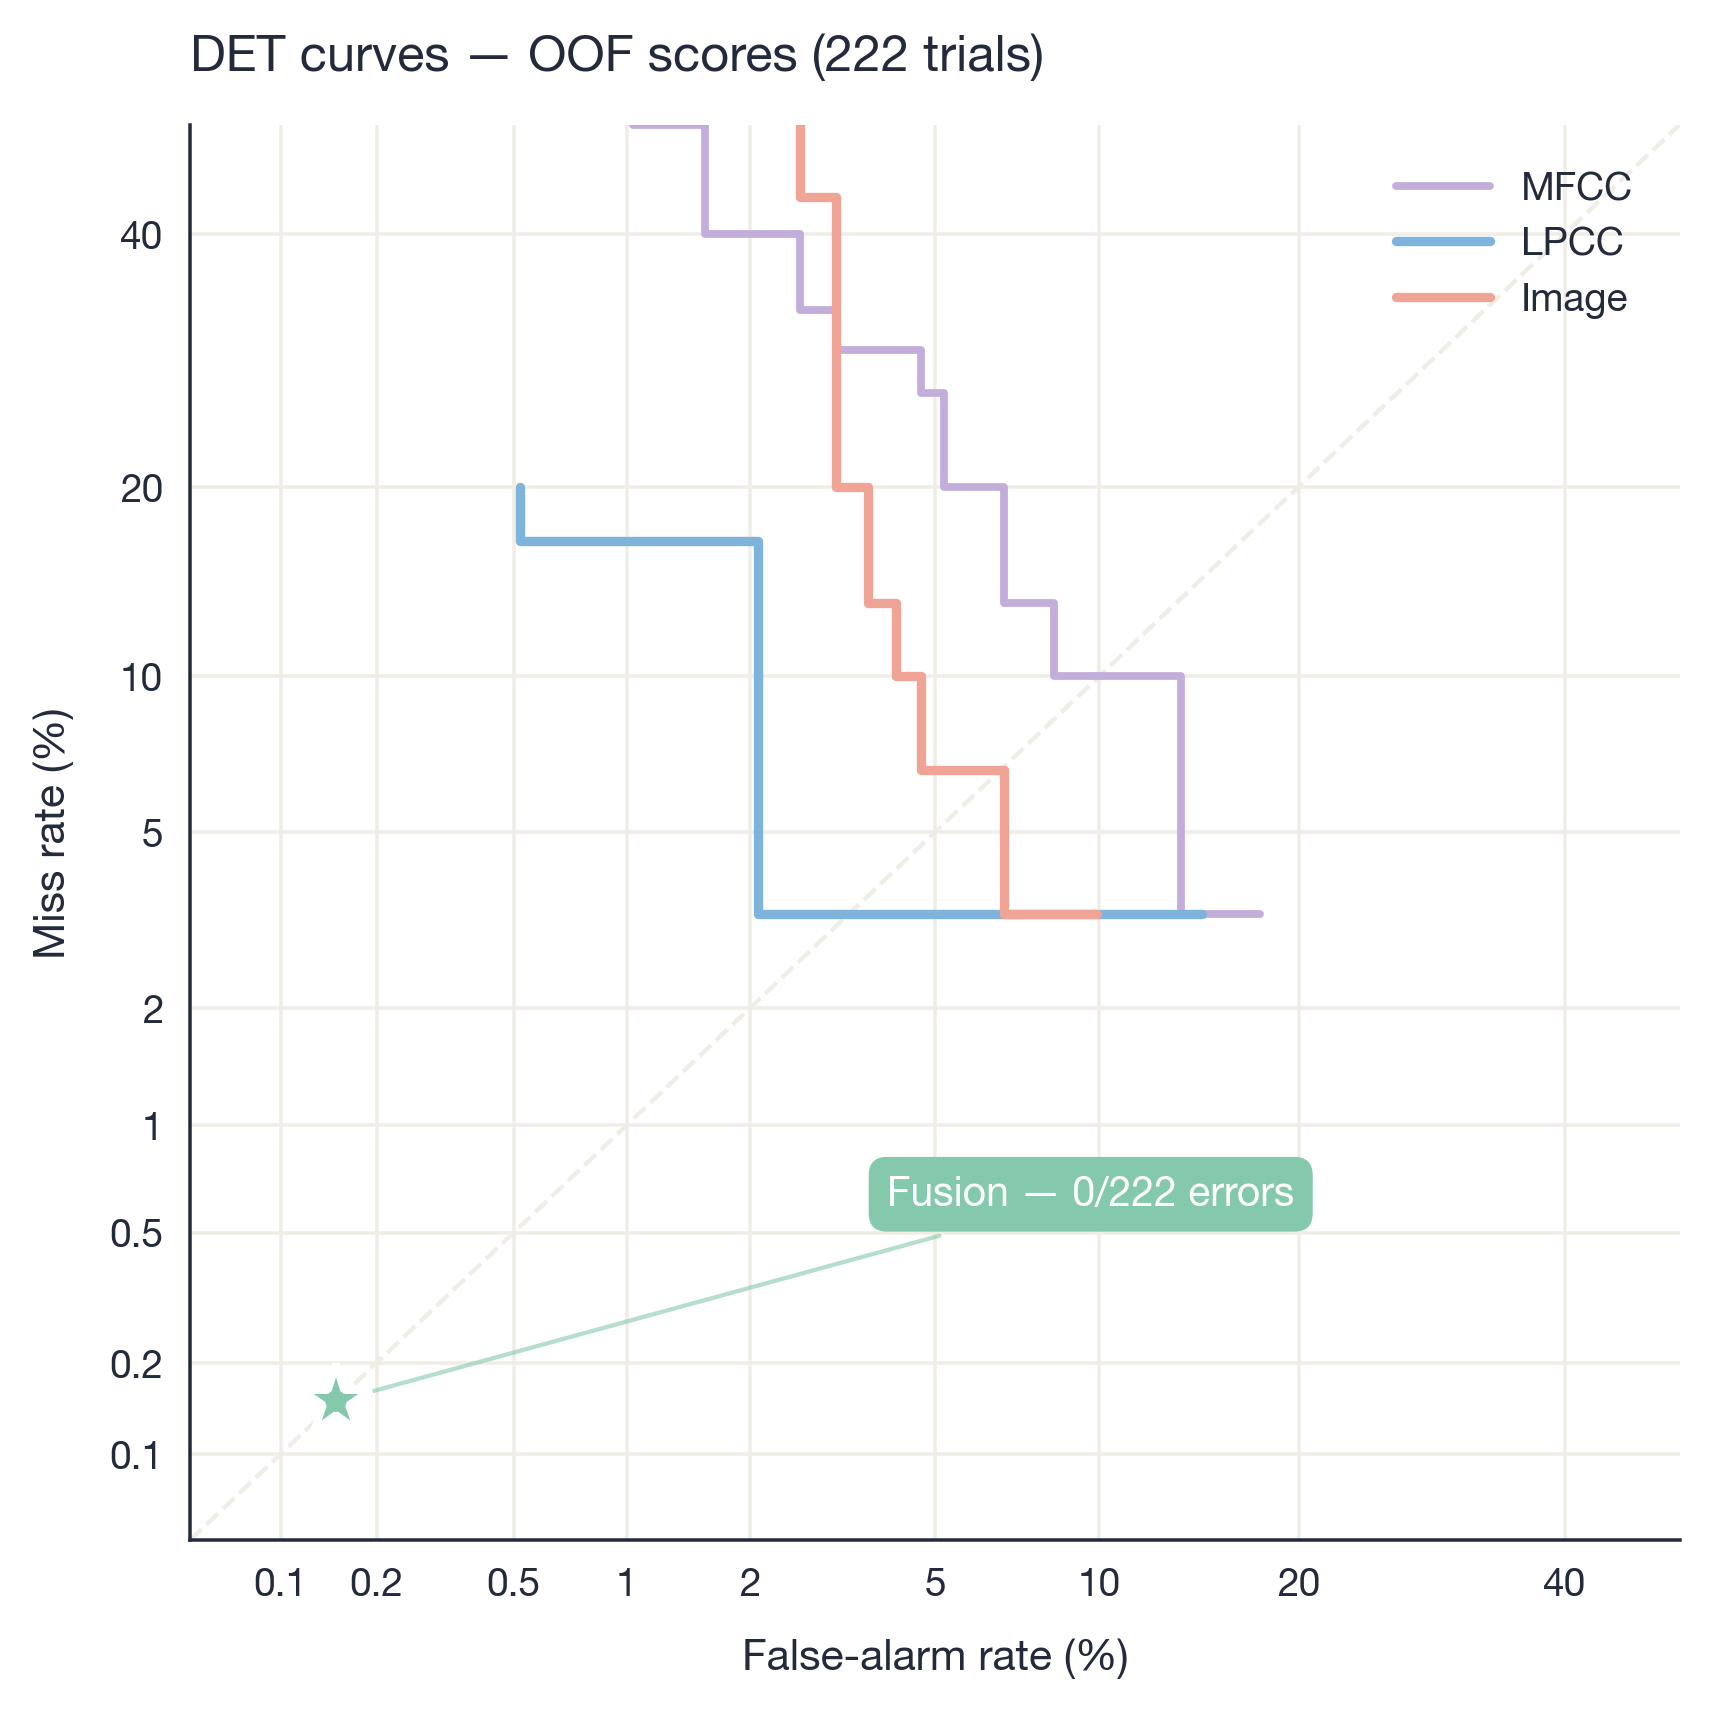

In [9]:
def det_axes(ax):
    ticks = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4]
    labs  = ["0.1", "0.2", "0.5", "1", "2", "5", "10", "20", "40"]
    ax.set_xticks([norm.ppf(t) for t in ticks]); ax.set_xticklabels(labs)
    ax.set_yticks([norm.ppf(t) for t in ticks]); ax.set_yticklabels(labs)
    lo, hi = norm.ppf(0.0005), norm.ppf(0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.plot([lo, hi], [lo, hi], "--", color=P["grid"], linewidth=1.1, zorder=0)
    ax.grid(which="both", color=P["grid"], linewidth=0.9, alpha=1.0, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("False-alarm rate (%)")
    ax.set_ylabel("Miss rate (%)")


def det_points(s_tar, s_non):
    y = np.r_[np.ones_like(s_tar), np.zeros_like(s_non)]
    s = np.r_[s_tar, s_non]
    fpr, tpr, _ = roc_curve(y, s)
    far, frr    = fpr, 1.0 - tpr
    m = (far > 0) & (far < 1) & (frr > 0) & (frr < 1)
    return norm.ppf(far[m]), norm.ppf(frr[m])


streams = [
    ("MFCC",   scores["mfcc"],   P["violet"], 2.0),
    ("LPCC",   scores["lpcc"],   P["audio"],  2.4),
    ("Image",  scores["image"],  P["image"],  2.4),
    ("Fusion", scores["fusion"], P["fusion"], 2.8),
]
y = scores["y"]

fig, ax = plt.subplots(figsize=(6.2, 6.2))
det_axes(ax)
for name, s, c, lw in streams:
    xx, yy = det_points(s[y == 1], s[y == 0])
    if len(xx) == 0:
        x0, y0 = norm.ppf(0.0015), norm.ppf(0.0015)
        ax.plot(x0, y0, marker="*", markersize=19, color=c,
                markeredgecolor="white", markeredgewidth=2.0,
                linestyle="None", zorder=5)
        ax.annotate(
            f"{name} — 0/222 errors",
            xy=(x0, y0), xytext=(norm.ppf(0.04), norm.ppf(0.006)),
            fontsize=10.5, color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.45", fc=c, ec="none"),
            arrowprops=dict(arrowstyle="-", color=c, lw=1.1, alpha=0.6,
                            shrinkA=4, shrinkB=10),
        )
    else:
        ax.plot(xx, yy, color=c, linewidth=lw, label=name,
                solid_capstyle="round", zorder=4)

ax.set_title("DET curves — OOF scores (222 trials)")
leg = ax.legend(loc="upper right", handlelength=2.4, borderaxespad=0.8)
for t in leg.get_texts():
    t.set_color(P["ink"])
fig.tight_layout()
save(fig, "fig6_det_curve")
plt.show()

## Figure 7 — Fused OOF score distribution

Non-target = pale lilac, target = pastel mint. KDE outlines overlaid.
Bayes threshold (log-odds = 0, prior 0.5) sits in the clear gap —
visual proof of 0/222 errors.

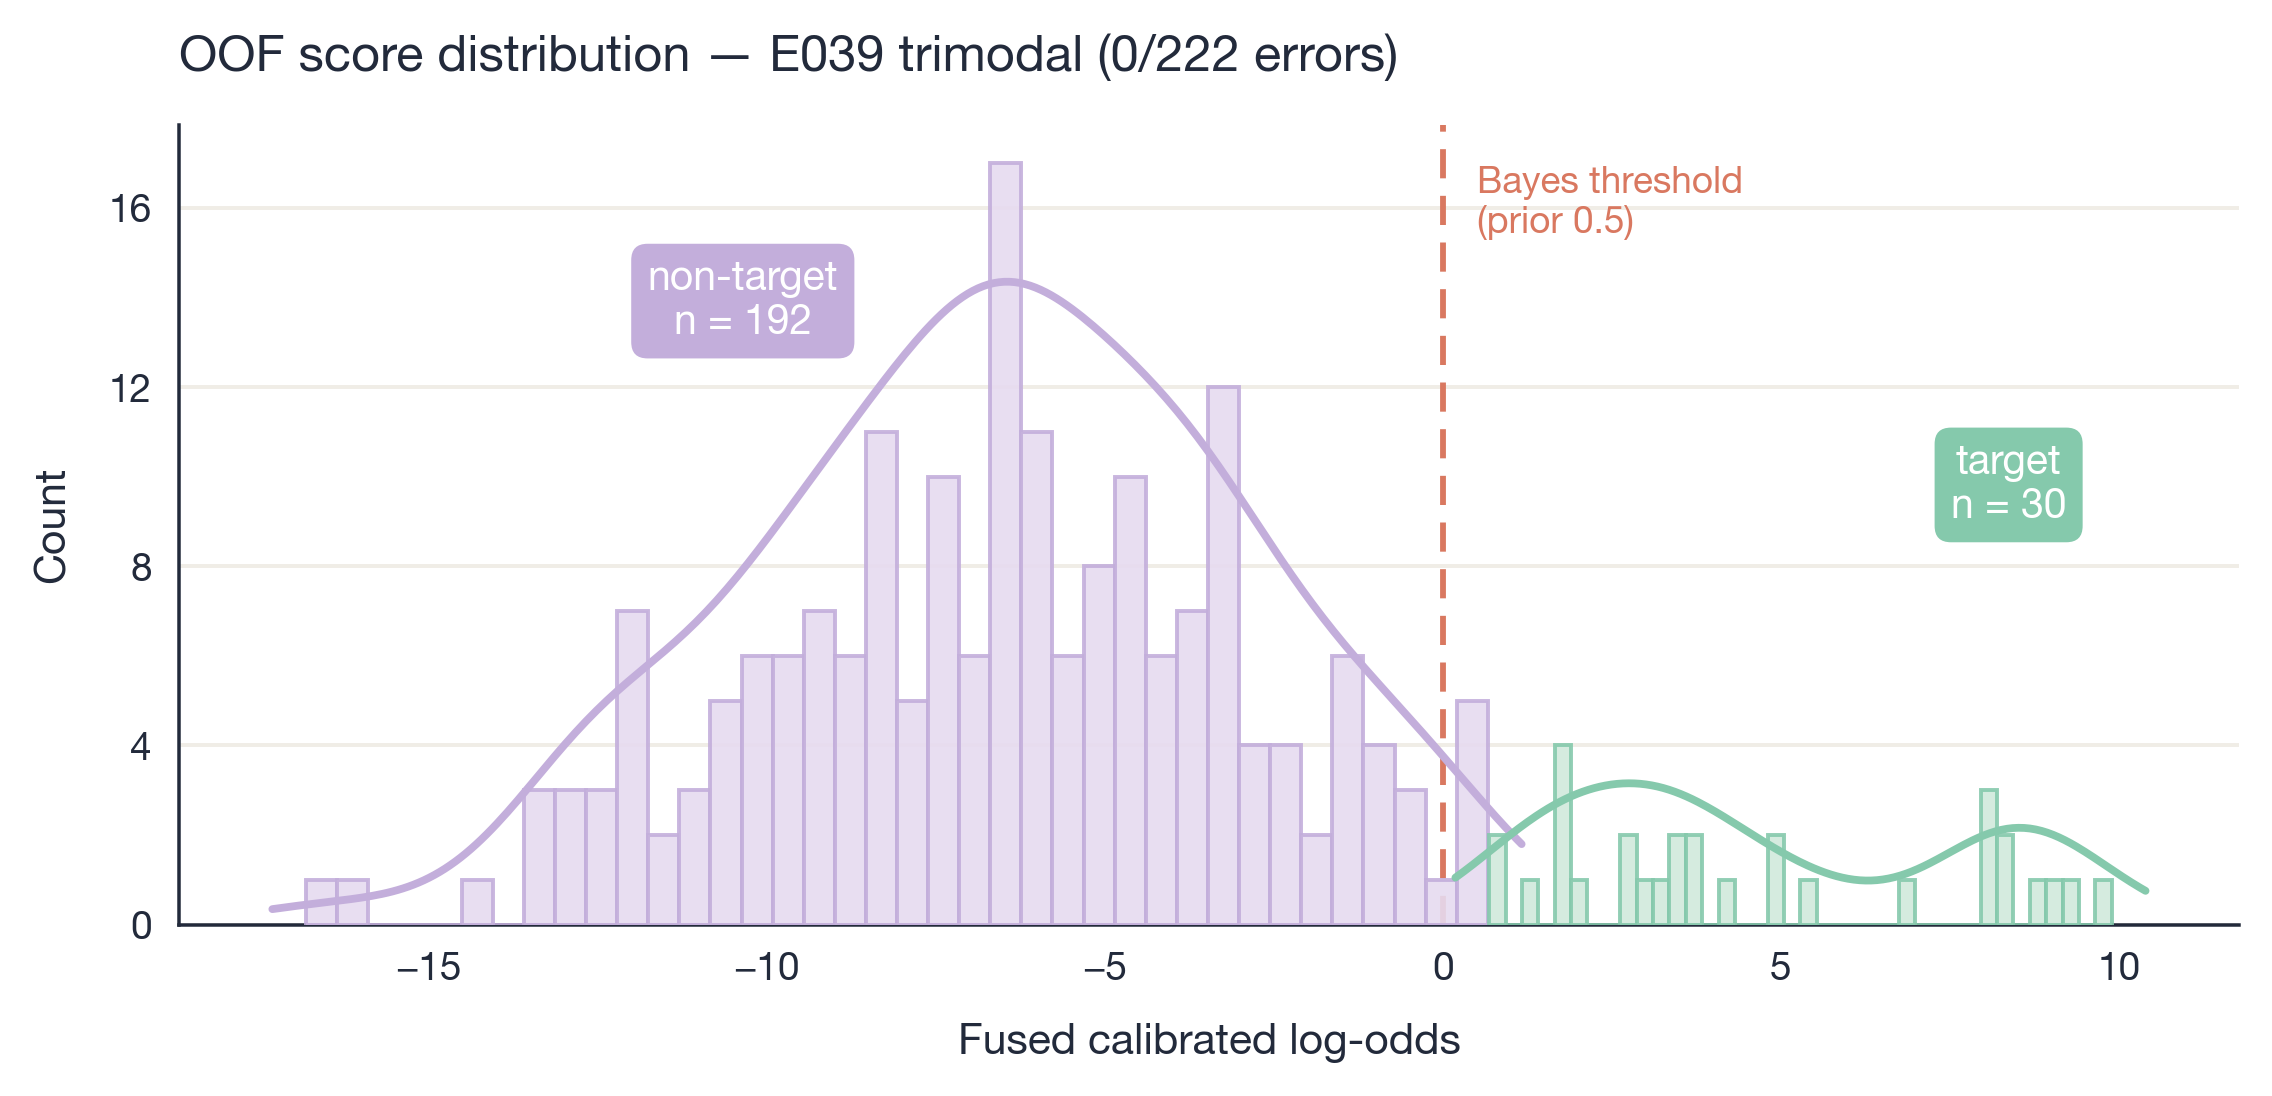

In [10]:
fused = scores["fusion"]; y = scores["y"]
sdf = pd.DataFrame({
    "score": fused,
    "class": np.where(y == 1, "target", "non-target"),
})
hist_col  = {"non-target": P["violet_pale"], "target": P["fusion_pale"]}
line_col  = {"non-target": P["violet"],       "target": P["fusion"]}
order     = ["non-target", "target"]

fig, ax = plt.subplots(figsize=(8.2, 4.0))
bin_width = (sdf["score"].max() - sdf["score"].min()) / 38

for cls in order:
    vals = sdf[sdf["class"] == cls]["score"].to_numpy()
    ax.hist(vals, bins=38, color=hist_col[cls], edgecolor=line_col[cls],
            linewidth=1.0, alpha=0.9, zorder=3)
    kde = gaussian_kde(vals, bw_method=0.35)
    grid = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 240)
    ax.plot(grid, kde(grid) * len(vals) * bin_width,
            color=line_col[cls], linewidth=2.0, zorder=4)

ax.axvline(0, color=P["accent"], linestyle=(0, (5, 3)), linewidth=1.5, zorder=2)
style(ax, y_label="Count", title="OOF score distribution — E039 trimodal (0/222 errors)")
ax.set_xlabel("Fused calibrated log-odds")

ymax = ax.get_ylim()[1]

# Threshold label — placed above the plot area between the two histograms.
ax.text(0.5, ymax * 0.95, "Bayes threshold\n(prior 0.5)",
        fontsize=9.5, color=P["accent"], fontweight="semibold",
        ha="left", va="top")

# Inline class labels — upper-left for non-target, upper-right for target.
non_vals = sdf[sdf["class"] == "non-target"]["score"]
tar_vals = sdf[sdf["class"] == "target"]["score"]
ax.text(non_vals.quantile(0.15), ymax * 0.78,
        f"non-target\nn = {(y == 0).sum()}",
        ha="center", va="center", fontsize=10.5, color="white",
        fontweight="semibold",
        bbox=dict(boxstyle="round,pad=0.4", fc=P["violet"], ec="none"))
ax.text(tar_vals.quantile(0.85), ymax * 0.55,
        f"target\nn = {(y == 1).sum()}",
        ha="center", va="center", fontsize=10.5, color="white",
        fontweight="semibold",
        bbox=dict(boxstyle="round,pad=0.4", fc=P["fusion"], ec="none"))

fig.tight_layout()
save(fig, "fig7_score_histogram")
plt.show()

### Done — 7 figures written to `docs/figures/`.